# Engenharia Econômica — Aula 5: Sistemas de Amortização

**Base:** *Engenharia Econômica - Aula 5 - Sistemas de Amortização.pdf* — Prof. Dr. Octaviano Rojas Luiz.

Este notebook transforma a Aula 5 em material executável e resolve os **6 exercícios do Trabalho 6**.

## Objetivos
- Diferenciar **juros**, **amortização** e **prestação**.
- Modelar **Pagamento Único**, **Sistema Americano (SAA)**, **Tabela Price** e **SAC**.
- Reproduzir os exercícios com Python.
- Comparar Price e SAC visualmente.

## 1. Fórmulas essenciais

\[
PMT_t = A_t + J_t
\]

\[
J_t = SD_{t-1}\cdot i
\]

\[
SD_t = SD_{t-1} - A_t
\]

### Tabela Price
\[
PMT = PV\cdot\frac{i(1+i)^n}{(1+i)^n-1}
\]

### SAC
\[
A=\frac{PV}{n}
\]

**Price:** prestação constante, juros decrescentes e amortização crescente.  
**SAC:** amortização constante, juros e prestações decrescentes.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def pmt_price(pv, i, n):
    return pv * (i * (1 + i)**n) / ((1 + i)**n - 1)

def tabela_price(pv, i, n):
    pmt = pmt_price(pv, i, n)
    saldo = pv
    linhas = []
    for mes in range(1, n + 1):
        juros = saldo * i
        amortizacao = pmt - juros
        saldo_final = saldo - amortizacao
        if abs(saldo_final) < 1e-8:
            saldo_final = 0.0
        linhas.append([mes, saldo, juros, amortizacao, pmt, saldo_final])
        saldo = saldo_final
    return pd.DataFrame(
        linhas,
        columns=["Mês", "Saldo Inicial", "Juros", "Amortização", "Prestação", "Saldo Final"]
    )

def tabela_sac(pv, i, n):
    amortizacao = pv / n
    saldo = pv
    linhas = []
    for mes in range(1, n + 1):
        juros = saldo * i
        pmt = amortizacao + juros
        saldo_final = saldo - amortizacao
        if abs(saldo_final) < 1e-8:
            saldo_final = 0.0
        linhas.append([mes, saldo, juros, amortizacao, pmt, saldo_final])
        saldo = saldo_final
    return pd.DataFrame(
        linhas,
        columns=["Mês", "Saldo Inicial", "Juros", "Amortização", "Prestação", "Saldo Final"]
    )

pd.options.display.float_format = lambda x: f"{x:,.2f}"

## 2. Exercício 1 — Pagamento Único / CDB

- Capital inicial: **R$ 50.000,00**
- Taxa: **1% a.m.**
- Prazo: **2 meses**

Como não há retirada no primeiro mês, os juros são incorporados ao saldo.

In [1]:
pv = 50_000
i = 0.01

juros_mes1 = pv * i
saldo_mes1 = pv + juros_mes1
juros_mes2 = saldo_mes1 * i
resgate_final = saldo_mes1 + juros_mes2

print(f"Juros do mês 1: R$ {juros_mes1:,.2f}")
print(f"Juros do mês 2: R$ {juros_mes2:,.2f}")
print(f"Resgate final:   R$ {resgate_final:,.2f}")

Juros do mês 1: R$ 500.00
Juros do mês 2: R$ 505.00
Resgate final:   R$ 51,005.00


**Resposta:** juros no mês 2 = **R$ 505,00**; resgate final = **R$ 51.005,00**.

## 3. Exercício 2 — Sistema Americano (SAA)

- Principal: **R$ 500.000,00**
- Taxa: **10% a.a.**
- Prazo: **5 anos**

No SAA, os juros são pagos periodicamente e o principal é quitado no final.

In [4]:
principal = 500_000
i = 0.10
n = 5

juros_anual = principal * i
linhas = []

for ano in range(1, n + 1):
    amortizacao = principal if ano == n else 0
    prestacao = juros_anual + amortizacao
    saldo_final = 0 if ano == n else principal
    linhas.append([ano, juros_anual, amortizacao, prestacao, saldo_final])

saa = pd.DataFrame(
    linhas,
    columns=["Ano", "Juros", "Amortização", "Prestação", "Saldo Final"]
)
saa

,Ano,Juros,Amortização,Prestação,Saldo Final
0,1,"50,000.00",0,"50,000.00",500000
1,2,"50,000.00",0,"50,000.00",500000
2,3,"50,000.00",0,"50,000.00",500000
3,4,"50,000.00",0,"50,000.00",500000
4,5,"50,000.00",500000,"550,000.00",0


**Resposta:** anos 1 a 4 = **R$ 50.000,00**; ano 5 = **R$ 550.000,00**.

## 4. Exercício 3 — Tabela Price

- Valor financiado: **R$ 10.000,00**
- Taxa: **2% a.m.**
- Prazo: **4 parcelas**

In [5]:
ex3 = tabela_price(10_000, 0.02, 4)
print(f"PMT = R$ {pmt_price(10_000, 0.02, 4):,.2f}")
ex3

PMT = R$ 2,626.24


,Mês,Saldo Inicial,Juros,Amortização,Prestação,Saldo Final
0,1,"10,000.00",200.00,"2,426.24","2,626.24","7,573.76"
1,2,"7,573.76",151.48,"2,474.76","2,626.24","5,099.00"
2,3,"5,099.00",101.98,"2,524.26","2,626.24","2,574.74"
3,4,"2,574.74",51.49,"2,574.74","2,626.24",0.00


A prestação fica em aproximadamente **R$ 2.626,24**.

O padrão esperado aparece na tabela:
- juros diminuem;
- amortização aumenta;
- prestação permanece constante.

## 5. Exercício 4 — 37ª parcela da Price

- Empréstimo: **R$ 80.000,00**
- Taxa: **2% a.m.**
- Prazo: **120 parcelas**
- Parcela analisada: **37ª**

Após 36 pagamentos, restam 84 prestações. O saldo devedor é o valor presente dessas parcelas restantes.

In [6]:
pv = 80_000
i = 0.02
n = 120
k = 36

pmt = pmt_price(pv, i, n)
restantes = n - k
sd36 = pmt * (1 - (1 + i)**(-restantes)) / i
j37 = sd36 * i
a37 = pmt - j37

print(f"PMT:  R$ {pmt:,.2f}")
print(f"SD36: R$ {sd36:,.2f}")
print(f"J37:  R$ {j37:,.2f}")
print(f"A37:  R$ {a37:,.2f}")

PMT:  R$ 1,763.85
SD36: R$ 71,480.84
J37:  R$ 1,429.62
A37:  R$ 334.23


Sem arredondamentos intermediários:

- **Juros da 37ª:** ≈ **R$ 1.429,62**
- **Amortização da 37ª:** ≈ **R$ 334,23**

Se você arredondar valores durante as etapas, podem surgir diferenças de poucos centavos.

## 6. Exercício 5 — SAC

- Financiamento: **R$ 240.000,00**
- Taxa: **2% a.m.**
- Prazo: **60 meses**

In [7]:
pv = 240_000
i = 0.02
n = 60

A = pv / n
sd15 = pv - 15 * A
j16 = sd15 * i
pmt16 = A + j16

print(f"Amortização fixa: R$ {A:,.2f}")
print(f"Saldo no mês 15:  R$ {sd15:,.2f}")
print(f"Juros da 16ª:     R$ {j16:,.2f}")
print(f"Prestação 16:     R$ {pmt16:,.2f}")

Amortização fixa: R$ 4,000.00
Saldo no mês 15:  R$ 180,000.00
Juros da 16ª:     R$ 3,600.00
Prestação 16:     R$ 7,600.00


**Resposta:** amortização fixa = **R$ 4.000,00**; saldo no mês 15 = **R$ 180.000,00**; prestação 16 = **R$ 7.600,00**.

## 7. Exercício 6 — Price x SAC

- Financiamento: **R$ 1.000.000,00**
- Taxa: **10% a.m.**
- Prazo: **5 meses**
- Premissa: **reduzir o desembolso do primeiro mês**

In [8]:
pv = 1_000_000
i = 0.10
n = 5

price = tabela_price(pv, i, n)
sac = tabela_sac(pv, i, n)

print(f"1ª parcela Price: R$ {price.loc[0, 'Prestação']:,.2f}")
print(f"1ª parcela SAC:   R$ {sac.loc[0, 'Prestação']:,.2f}")

comparativo = pd.DataFrame({
    "Mês": price["Mês"],
    "Price": price["Prestação"],
    "SAC": sac["Prestação"],
})
comparativo

1ª parcela Price: R$ 263,797.48
1ª parcela SAC:   R$ 300,000.00


,Mês,Price,SAC
0,1,"263,797.48","300,000.00"
1,2,"263,797.48","280,000.00"
2,3,"263,797.48","260,000.00"
3,4,"263,797.48","240,000.00"
4,5,"263,797.48","220,000.00"


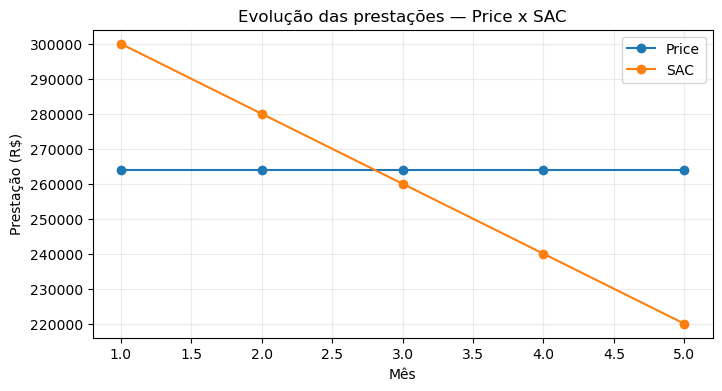

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(comparativo["Mês"], comparativo["Price"], marker="o", label="Price")
plt.plot(comparativo["Mês"], comparativo["SAC"], marker="o", label="SAC")
plt.title("Evolução das prestações — Price x SAC")
plt.xlabel("Mês")
plt.ylabel("Prestação (R$)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

**Decisão:** para a premissa de menor desembolso no primeiro mês, escolher **Price**.

- 1ª prestação Price ≈ **R$ 263.797,48**
- 1ª prestação SAC = **R$ 300.000,00**

O SAC, por outro lado, amortiza mais rapidamente e produz prestações decrescentes.

## 8. Resumo rápido

| Sistema | Constante | Comportamento |
|---|---|---|
| Pagamento Único | — | Tudo é pago no final |
| Americano | Principal até o vencimento | Juros periódicos + principal final |
| Price | Prestação | Juros ↓, amortização ↑ |
| SAC | Amortização | Juros ↓, prestação ↓ |

### Regra mental
- **Price:** parcela fixa.
- **SAC:** amortização fixa.
- **Americano:** juros agora, principal no fim.
- **Pagamento único:** tudo no fim.

## 9. Ligação com contabilidade e finanças

Esses modelos aparecem em:
- conciliação de empréstimos e financiamentos;
- separação entre principal e despesa financeira;
- projeção de fluxo de caixa;
- análise de endividamento;
- cálculo do custo de dívida.

A continuação natural é a **Aula 6**, implementando **VPL, TIR, Payback e VAE/CAUE**.